# Titanic - Analyse de la survie des passagers

Jeu de donnees : `titanic_data.csv`, 891 passagers et 12 colonnes.

Plan du notebook :

1. Chargement et inspection
2. Qualite des donnees et nettoyage
3. Analyse univariee
4. Analyse bivariee : qui a survecu ?
5. Correlations
6. Synthese

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", None)

## 1. Chargement et inspection

In [2]:
df = pd.read_csv("titanic_data.csv")
print("Dimensions :", df.shape)
df.head()

Dimensions : (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


## 2. Qualite des donnees et nettoyage

Trois colonnes posent probleme : `Age` (valeurs manquantes), `Embarked` (deux
valeurs manquantes) et `Cabin` (manquante pour la grande majorite des passagers).

In [5]:
manquantes = pd.DataFrame({
    "manquantes": df.isna().sum(),
    "part (%)": (df.isna().mean() * 100).round(1),
})
manquantes[manquantes["manquantes"] > 0].sort_values("manquantes", ascending=False)

,manquantes,part (%)
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2


In [6]:
clean = df.copy()

# Age : mediane par sexe et par classe, plus proche du profil du passager
# qu'une mediane globale.
clean["Age"] = clean.groupby(["Sex", "Pclass"])["Age"].transform(
    lambda s: s.fillna(s.median()))

# Embarked : deux valeurs manquantes seulement, on prend le port le plus frequent.
clean["Embarked"] = clean["Embarked"].fillna(clean["Embarked"].mode()[0])

# Cabin : trop incomplete pour etre exploitee telle quelle. On garde
# uniquement l'information "le numero de cabine est connu ou non".
clean["HasCabin"] = clean["Cabin"].notna().astype(int)
clean = clean.drop(columns=["Cabin"])

print("Valeurs manquantes restantes :", int(clean.isna().sum().sum()))
clean.head()

Valeurs manquantes restantes : 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,HasCabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


In [7]:
# Variables derivees utiles pour l'analyse bivariee
clean["FamilySize"] = clean["SibSp"] + clean["Parch"] + 1
clean["AgeBand"] = pd.cut(
    clean["Age"], bins=[0, 12, 18, 30, 45, 60, 100],
    labels=["0-12", "13-18", "19-30", "31-45", "46-60", "60+"])
clean["FareQuartile"] = pd.qcut(clean["Fare"], 4, labels=["Q1", "Q2", "Q3", "Q4"])
clean[["Age", "AgeBand", "Fare", "FareQuartile", "FamilySize"]].head()

,Age,AgeBand,Fare,FareQuartile,FamilySize
0,22.0,19-30,7.2500,Q1,2
1,38.0,31-45,71.2833,Q4,2
2,26.0,19-30,7.9250,Q2,1
3,35.0,31-45,53.1000,Q4,2
4,35.0,31-45,8.0500,Q2,1


## 3. Analyse univariee

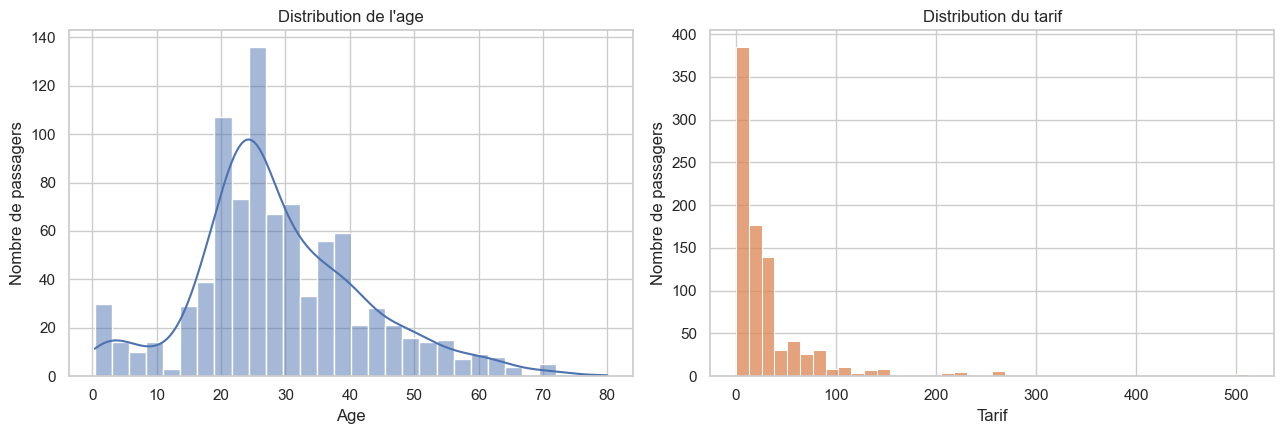

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(clean["Age"], bins=30, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution de l'age")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Nombre de passagers")

sns.histplot(clean["Fare"], bins=40, kde=False, ax=axes[1], color="#DD8452")
axes[1].set_title("Distribution du tarif")
axes[1].set_xlabel("Tarif")
axes[1].set_ylabel("Nombre de passagers")

plt.tight_layout()
plt.show()

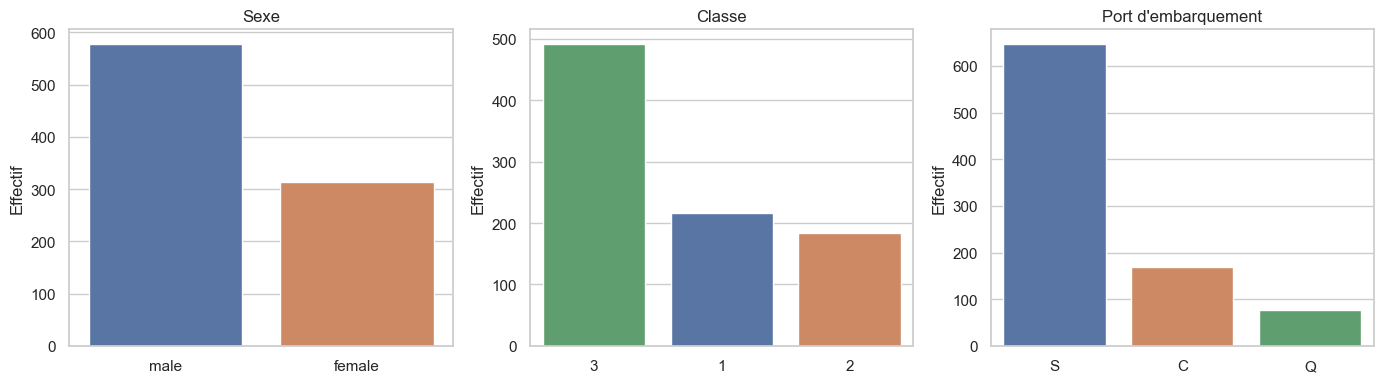

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, titre in zip(axes,
                          ["Sex", "Pclass", "Embarked"],
                          ["Sexe", "Classe", "Port d'embarquement"]):
    ordre = clean[col].value_counts().index
    sns.countplot(data=clean, x=col, order=ordre, ax=ax, hue=col,
                  palette="deep", legend=False)
    ax.set_title(titre)
    ax.set_xlabel("")
    ax.set_ylabel("Effectif")

plt.tight_layout()
plt.show()

In [10]:
taux_global = clean["Survived"].mean()
print("Taux de survie global : {:.1%}".format(taux_global))
print(clean["Survived"].value_counts().rename({0: "Decede", 1: "Survivant"}))

Taux de survie global : 38.4%
Survived
Decede       549
Survivant    342
Name: count, dtype: int64


## 4. Analyse bivariee : qui a survecu ?

On compare le taux de survie selon les principales variables qualitatives.

In [11]:
def taux_survie(colonne):
    t = (clean.groupby(colonne, observed=True)["Survived"]
         .agg(effectif="size", taux="mean"))
    t["taux"] = (t["taux"] * 100).round(1)
    return t


for col in ["Sex", "Pclass", "Embarked", "AgeBand", "FareQuartile", "HasCabin"]:
    print("", col)
    print(taux_survie(col))
    print()

 Sex
        effectif  taux
Sex                   
female       314  74.2
male         577  18.9

 Pclass
        effectif  taux
Pclass                
1            216  63.0
2            184  47.3
3            491  24.2

 Embarked
          effectif  taux
Embarked                
C              168  55.4
Q               77  39.0
S              646  33.9

 AgeBand
         effectif  taux
AgeBand                
0-12           69  58.0
13-18          70  42.9
19-30         417  32.1
31-45         232  43.1
46-60          81  40.7
60+            22  22.7

 FareQuartile
              effectif  taux
FareQuartile                
Q1                 223  19.7
Q2                 224  30.4
Q3                 222  45.5
Q4                 222  58.1

 HasCabin
          effectif  taux
HasCabin                
0              687  30.0
1              204  66.7



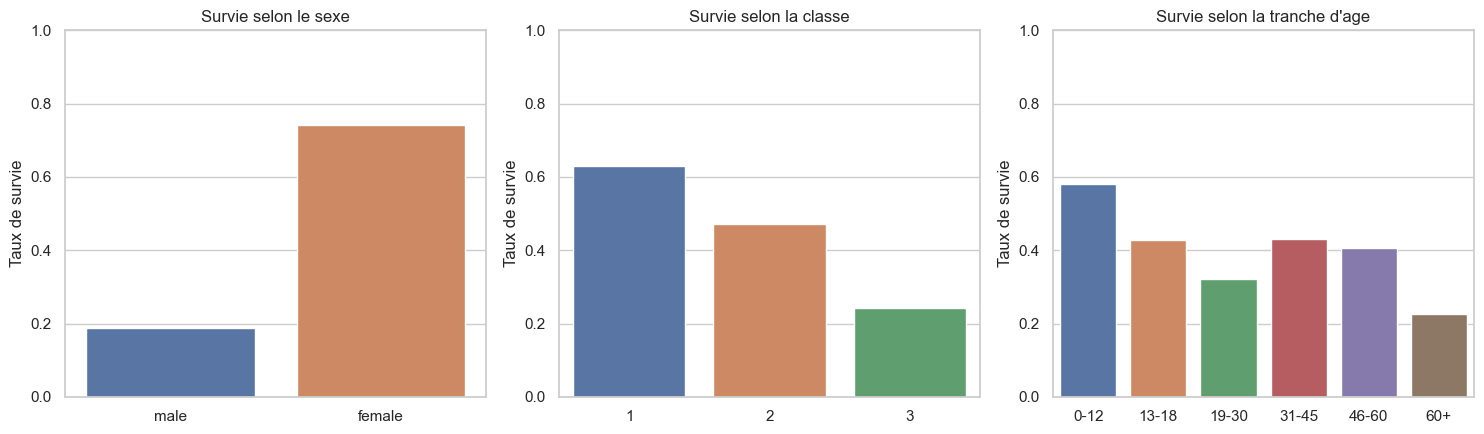

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.barplot(data=clean, x="Sex", y="Survived", ax=axes[0],
            hue="Sex", palette="deep", legend=False, errorbar=None)
axes[0].set_title("Survie selon le sexe")

sns.barplot(data=clean, x="Pclass", y="Survived", ax=axes[1],
            hue="Pclass", palette="deep", legend=False, errorbar=None)
axes[1].set_title("Survie selon la classe")

sns.barplot(data=clean, x="AgeBand", y="Survived", ax=axes[2],
            hue="AgeBand", palette="deep", legend=False, errorbar=None)
axes[2].set_title("Survie selon la tranche d'age")

for ax in axes:
    ax.set_ylabel("Taux de survie")
    ax.set_ylim(0, 1)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

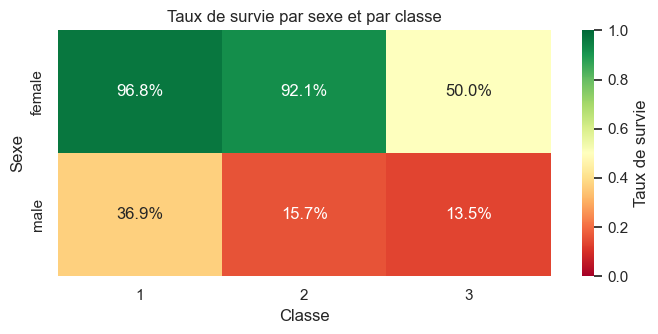

In [13]:
pivot = clean.pivot_table(index="Sex", columns="Pclass",
                          values="Survived", aggfunc="mean")

plt.figure(figsize=(7, 3.5))
sns.heatmap(pivot, annot=True, fmt=".1%", cmap="RdYlGn", vmin=0, vmax=1,
            cbar_kws={"label": "Taux de survie"})
plt.title("Taux de survie par sexe et par classe")
plt.ylabel("Sexe")
plt.xlabel("Classe")
plt.tight_layout()
plt.show()

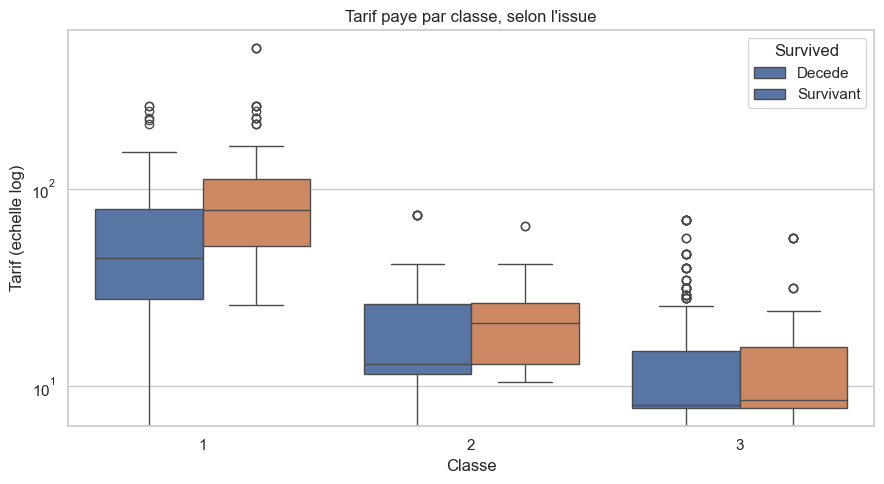

In [14]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=clean, x="Pclass", y="Fare", hue="Survived", palette="deep")
plt.yscale("log")
plt.title("Tarif paye par classe, selon l'issue")
plt.xlabel("Classe")
plt.ylabel("Tarif (echelle log)")
plt.legend(title="Survived", labels=["Decede", "Survivant"])
plt.tight_layout()
plt.show()

## 5. Correlations entre variables numeriques

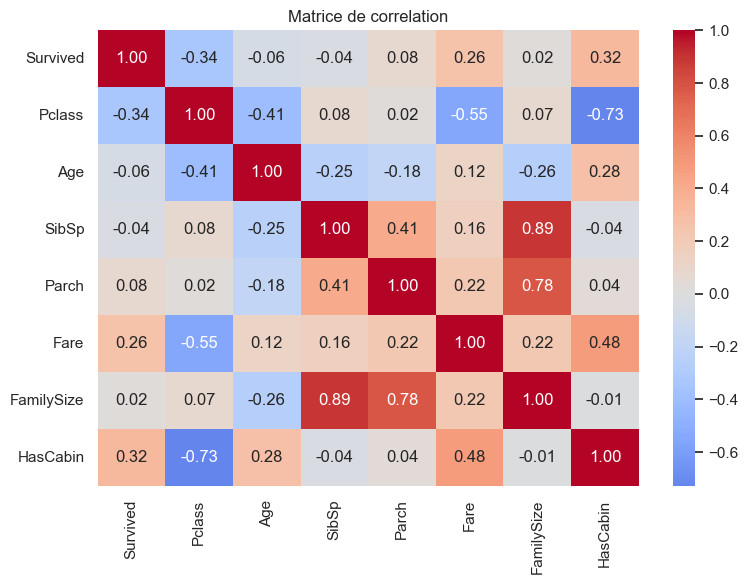

Pclass       -0.34
Age          -0.06
SibSp        -0.04
FamilySize    0.02
Parch         0.08
Fare          0.26
HasCabin      0.32
Name: Survived, dtype: float64

In [15]:
num = clean[["Survived", "Pclass", "Age", "SibSp", "Parch",
             "Fare", "FamilySize", "HasCabin"]]
corr = num.corr().round(2)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matrice de correlation")
plt.tight_layout()
plt.show()

corr["Survived"].drop("Survived").sort_values()

## 6. Synthese

- Le sexe est de loin le facteur le plus discriminant : les femmes survivent
  bien plus souvent que les hommes.
- La classe joue ensuite : plus la classe est elevee, plus le taux de survie
  monte, et cet effet se cumule avec celui du sexe.
- Le tarif va dans le meme sens que la classe, ce qui est logique puisque les
  deux mesurent la meme chose.
- L'age compte surtout aux extremites : les enfants s'en sortent mieux que la
  moyenne, les tranches adultes se ressemblent.
- Le fait de disposer d'un numero de cabine est correle positivement a la
  survie, mais c'est un effet indirect : les cabines renseignees sont
  principalement celles de premiere classe.